In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from typing import Optional

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_faceted_benchmarking_grid_with_error(df: pd.DataFrame) -> None:
    """
    Plots faceted line charts with error bars for benchmarking metrics vs n_circuits.
    Facets by metric and num_ancilla. Error bars reflect standard deviation.

    Parameters:
        df (pd.DataFrame): Grouped DataFrame with mean and std columns.

    Returns:
        None
    """
    metrics = ["runtime", "peak_MB", "estimation_error", "est_energy_med"]
    for metric in metrics:
        df[f"{metric}_err"] = df[f"{metric}_std"]

    melted = pd.melt(
        df,
        id_vars=["n_circuits", "n_shots", "num_ancilla"],
        value_vars=[f"{m}_mean" for m in metrics],
        var_name="metric",
        value_name="value"
    )

    # Map error columns for plotting
    metric_err_map = {f"{m}_mean": f"{m}_err" for m in metrics}
    melted["error"] = melted["metric"].map(metric_err_map).map(df.set_index(["n_circuits", "n_shots", "num_ancilla"]).to_dict()[df.columns[-1]])

    g = sns.FacetGrid(melted, col="metric", row="num_ancilla", hue="n_shots", margin_titles=True, sharey=False)

    def plot_with_err(data, **kwargs):
        for shot_val, group in data.groupby("n_shots"):
            plt.errorbar(group["n_circuits"], group["value"], yerr=group["error"], fmt='-o', label=f"shots={shot_val}")
        plt.legend()

    g.map_dataframe(plot_with_err)
    plt.tight_layout()
    plt.show()


def plot_metric_pairwise_relationships(df: pd.DataFrame) -> None:
    """
    Creates a seaborn pairplot showing correlations between runtime, peak_MB,
    estimation_error, and est_energy_std colored by num_ancilla.

    Parameters:
        df (pd.DataFrame): A DataFrame with mean benchmarking metrics,
                           must include 'num_ancilla' column.

    Returns:
        None: Displays the pairplot.
    """
    metrics_df = df[["runtime", "peak_MB", "estimation_error", "est_energy_std", "num_ancilla"]]

    sns.pairplot(metrics_df, hue="num_ancilla", palette="Set2", diag_kind="kde", corner=True)
    plt.suptitle("Metric Relationships by Number of Ancilla Qubits", y=1.02)
    plt.show()


def plot_metrics_vs_runtime_with_error(df: pd.DataFrame) -> None:
    """
    Plots runtime vs [estimation_error, peak_MB, est_energy_std] with error bars.
    Includes log-log scale and distinguishes n_shots and num_ancilla.

    Parameters:
        df (pd.DataFrame): Grouped DataFrame with _mean and _std columns.

    Returns:
        None
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
    plots = [
        ("estimation_error_mean", "estimation_error_std", "Estimation Error"),
        ("peak_MB_mean", "peak_MB_std", "Peak Memory"),
        ("est_energy_std_mean", "est_energy_std_std", "Energy Std")
    ]

    for ax, (y_col, yerr_col, title) in zip(axes, plots):
        for (n_shots, num_ancilla), group in df.groupby(["n_shots", "num_ancilla"]):
            ax.errorbar(group["runtime_mean"], group[y_col], 
                        yerr=group[yerr_col], fmt='o-', label=f"{n_shots} shots, {num_ancilla} ancilla")

        ax.set_title(f"{title} vs Runtime")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Runtime")
        ax.legend(fontsize="small")

    plt.tight_layout()
    plt.show()


In [28]:
df_raw = pd.read_csv("qdrift_qpe_fc_parameter_sweep_2025-07-31.csv")
df_raw.drop(columns=[
    "ham", "counts", "depth", "exact_eig", "most_likely_bs", "replication_seed", 
    "segments", "est_energy_min", "est_energy_max", "num_system_qubits", "time", 
    "size", "alpha", "est_energy_mean"
], inplace=True)

df = df_raw.groupby(["n_circuits", "n_shots", "num_ancilla"]).agg(["mean", "std"]).reset_index()
# Flatten multi-index columns
df.columns = ['_'.join(col).strip('_') for col in df.columns.values]
df

,n_circuits,n_shots,num_ancilla,peak_MB_mean,peak_MB_std,runtime_mean,runtime_std,est_energy_med_mean,est_energy_med_std,est_energy_std_mean,est_energy_std_std,estimation_error_mean,estimation_error_std
0,1,1,12,397.039062,20.459179,8.193040,0.385701,0.145504,0.528467,0.0,0.0,0.300830,0.464761
1,1,1,14,930.784648,27.121161,39.353127,1.617357,0.426216,0.571311,0.0,0.0,0.236403,0.532004
2,1,1,16,2946.540781,111.645600,533.758725,113.892674,0.418496,0.651132,0.0,0.0,0.280363,0.596609
3,1,1,18,9347.605239,1452.029061,4432.225841,3041.921672,0.276275,0.151691,0.0,0.0,0.042297,0.149988


C:\Users\Ro\AppData\Local\Temp\ipykernel_17912\367944163.py:89: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


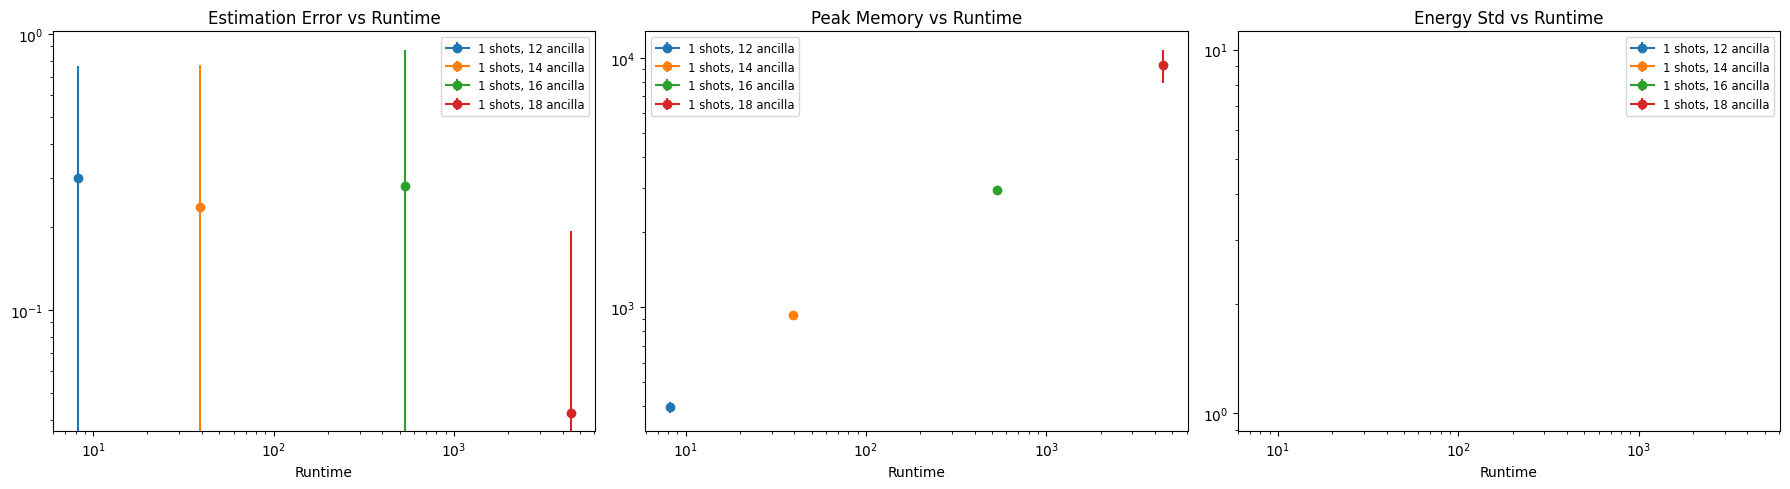

In [26]:
plot_metrics_vs_runtime_with_error(df)

In [ ]:

def load_and_merge_qpe_csvs(directory: str) -> pd.DataFrame:
    """
    Loads all QPE result CSV files from a directory into a single master DataFrame.

    Assumes each CSV follows identical structure.

    Parameters:
        directory (str): Path to the folder containing CSV files.

    Returns:
        pd.DataFrame: Concatenated master DataFrame.
    """
    dfs = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            filepath = os.path.join(directory, filename)
            try:
                df = pd.read_csv(filepath)
                df['source_file'] = filename  # Optional: track origin
                dfs.append(df)
            except Exception as e:
                print(f"Error reading {filename}: {e}")

    if not dfs:
        raise ValueError("No valid CSV files found in the directory.")

    master_df = pd.concat(dfs, ignore_index=True)

    return master_df


In [72]:
master_df = load_and_merge_qpe_csvs("../../results/parameter_sweep")

columns_to_drop = [
    "ham", "depth", "exact_eig", "most_likely_bs", "replication_seed",
    "segments", "est_energy_min", "est_energy_max", "num_system_qubits",
    "time", "size", "est_energy_mean", "counts"
]
master_df.drop(columns=[c for c in columns_to_drop if c in master_df.columns], inplace=True)
grouped = master_df.groupby(["alpha", "num_ancilla", "n_circuits", "n_shots"]).agg(
    runtime_mean=("runtime", "mean"),
    runtime_std=("runtime", "std"),
    error_mean=("estimation_error", "mean"),
    error_std=("estimation_error", "std"),
).reset_index()

# sort by error_mean
grouped.sort_values(by="error_mean", inplace=True)
grouped.head(20)

,alpha,num_ancilla,n_circuits,n_shots,runtime_mean,runtime_std,error_mean,error_std
7,0.44,18,1,1,4432.225841,3041.921672,0.042297,0.149988
4,0.44,12,100,1,1035.599506,39.721334,0.065133,0.105565
2,0.44,10,100,1,294.565801,1.143743,0.119445,0.136510
14,2.20,12,100,1,4771.717809,2110.735974,0.121906,0.126912
15,2.20,12,100,100,40879.763453,20440.993486,0.151238,0.135421
1,0.44,8,100,1,115.437794,2.518197,0.174521,0.141512
0,0.44,6,100,1,74.663671,4.636718,0.228477,0.125684
5,0.44,14,1,1,39.353127,1.617357,0.236403,0.532004
6,0.44,16,1,1,533.758725,113.892674,0.280363,0.596609
3,0.44,12,1,1,8.193040,0.385701,0.300830,0.464761


In [58]:
# Plotting function to visualize effects of experimental parameters on key metrics
def plot_param_impact_on_metrics(df: pd.DataFrame) -> None:
    """
    Creates pairwise plots to visualize how experimental parameters (n_circuits, n_shots,
    num_ancilla, alpha) impact metrics like peak_MB, runtime, and estimation_error.

    Args:
        df (pd.DataFrame): DataFrame containing the simulation results.

    Returns:
        None. Displays the plots.
    """
    # Extract and rename relevant columns
    plot_df = df[[
        "n_circuits", "n_shots", "num_ancilla", "alpha",
        "peak_MB", "runtime", "estimation_error"
    ]].copy()
    
    # Drop rows with NaN values in key columns
    plot_df.dropna(subset=["peak_MB", "runtime", "estimation_error"], inplace=True)

    # Normalize alpha for better plotting (optional aesthetic)
    plot_df["alpha"] = plot_df["alpha"].round(3)

    # Pairplot to see all relationships with hue = alpha for fine color gradation
    sns.set(style="whitegrid", context="notebook", font_scale=1.2)
    g = sns.pairplot(
        plot_df,
        hue="alpha",
        palette="viridis",
        diag_kind="kde",
        corner=True,
        plot_kws={"alpha": 0.7, "s": 40, "edgecolor": "k"}
    )
    g.fig.suptitle("Impact of Experimental Parameters on Simulation Metrics", y=1.02)
    plt.show()

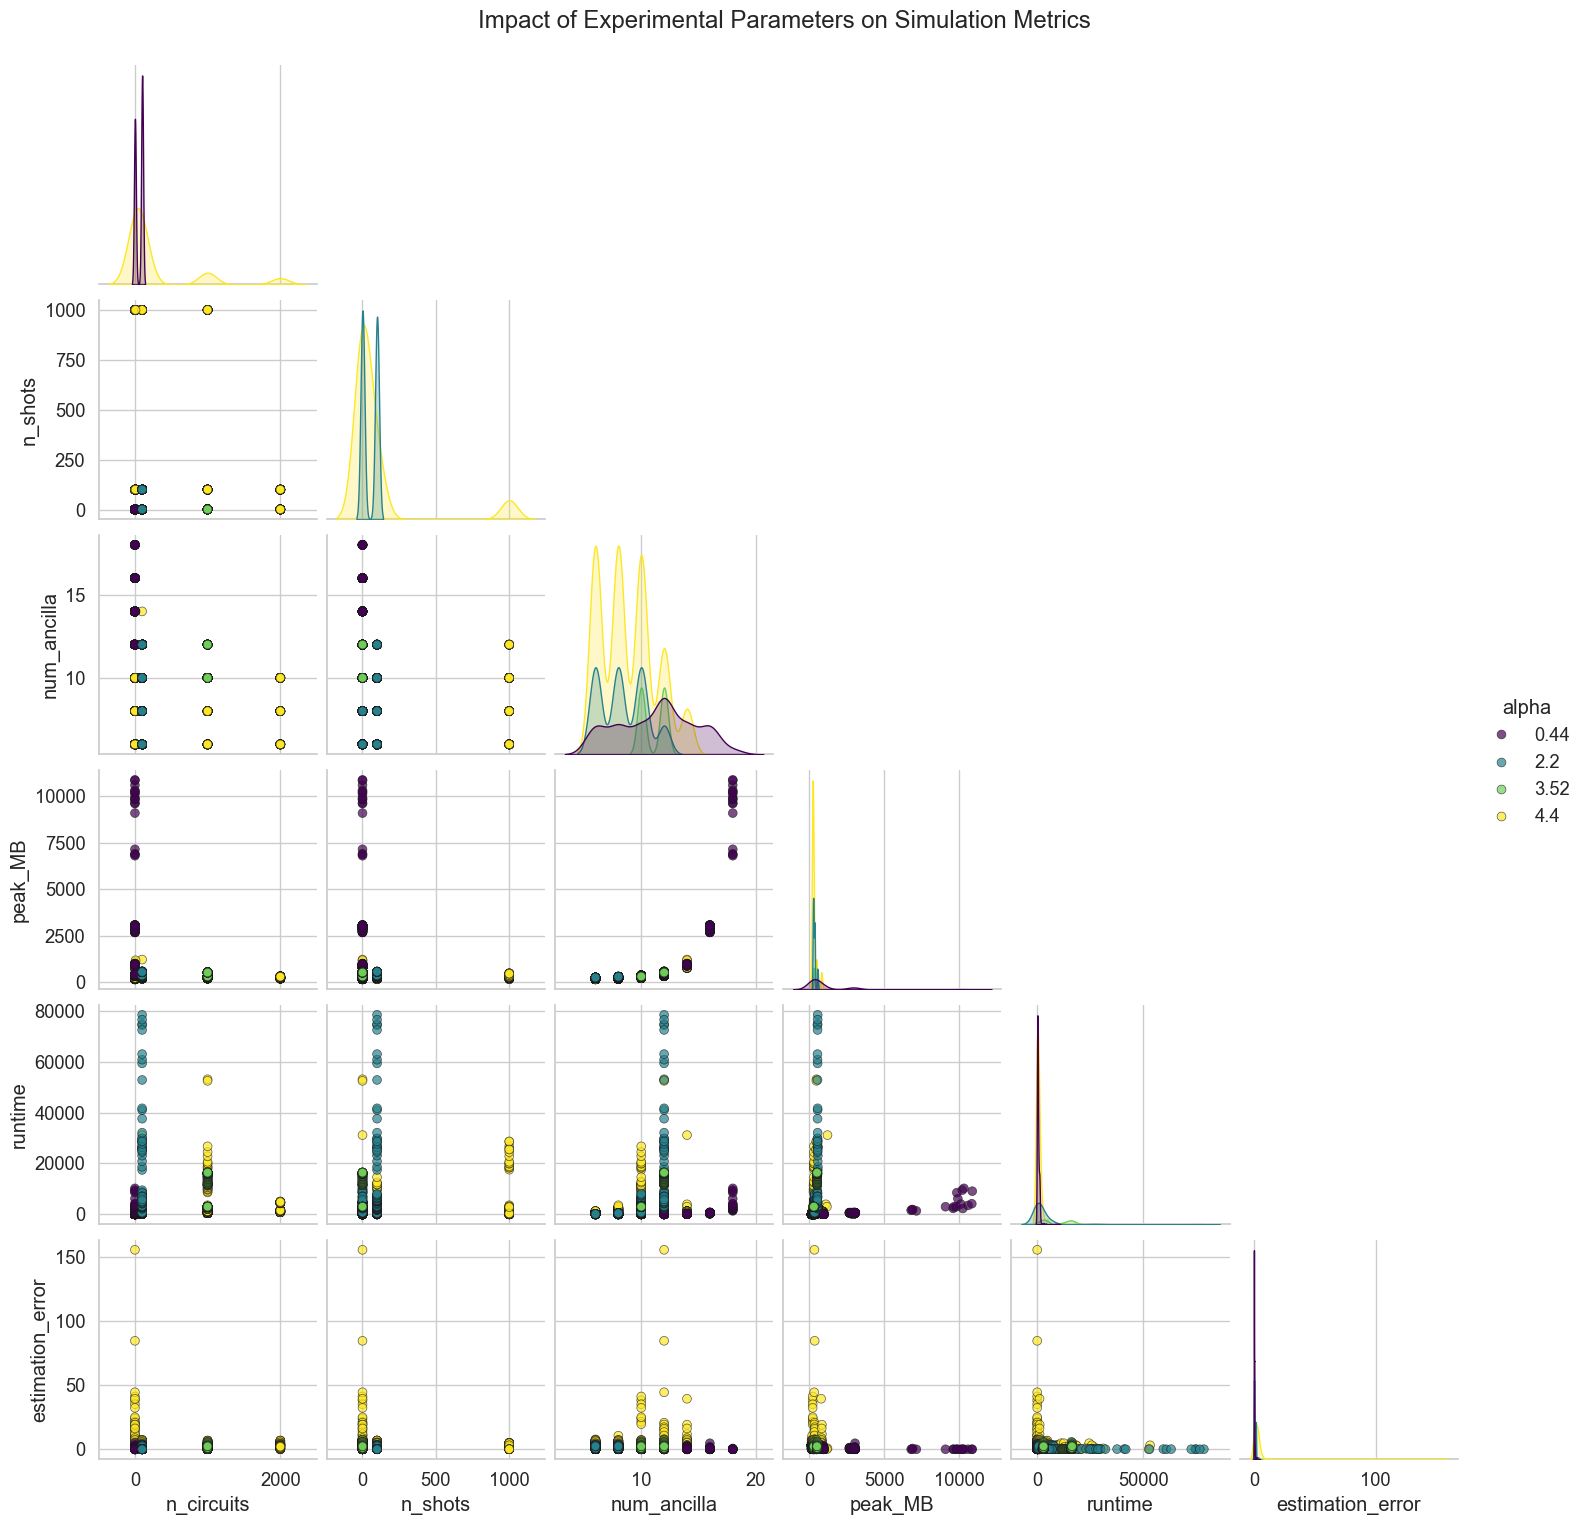

In [62]:
plot_param_impact_on_metrics(master_df)

In [73]:
def plot_avg_metrics_vs_ancilla(
    df: pd.DataFrame,
    metric_cols: list[str] = ["runtime", "peak_MB", "estimation_error"],
    figsize: tuple[int, int] = (18, 5)
) -> None:
    """
    Load a CSV dataset, group by number of ancilla qubits, and plot average metrics vs number of ancilla qubits.

    Parameters:
    -----------
    csv_path : str
        Path to the CSV file.
    drop_cols : list[str], optional
        List of columns to drop from the DataFrame. If None, a default list is used.
    metric_cols : list[str]
        List of metric columns to plot. Default includes runtime, peak_MB, and estimation_error.
    figsize : tuple[int, int]
        Size of the full figure containing subplots.
    """

    # Group by num_ancilla and compute mean and std for error bars
    df_mean = df.groupby("num_ancilla").mean(numeric_only=True)
    df_std = df.groupby("num_ancilla").std(numeric_only=True)

    # Plotting
    fig, axs = plt.subplots(1, len(metric_cols), figsize=figsize)
    for ax, metric in zip(axs, metric_cols):
        ax.errorbar(
            df_mean.index,
            df_mean[metric],
            yerr=df_std[metric],
            fmt='-o',
            capsize=4,
            label=f'Avg {metric.replace("_", " ").title()}'
        )
        ax.set_title(f'Average {metric.replace("_", " ").title()} vs Number of Ancilla Qubits')
        ax.set_xlabel('Number of Ancilla Qubits')
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.grid(True)
        ax.legend()
    plt.tight_layout()
    plt.show()


Group: 1


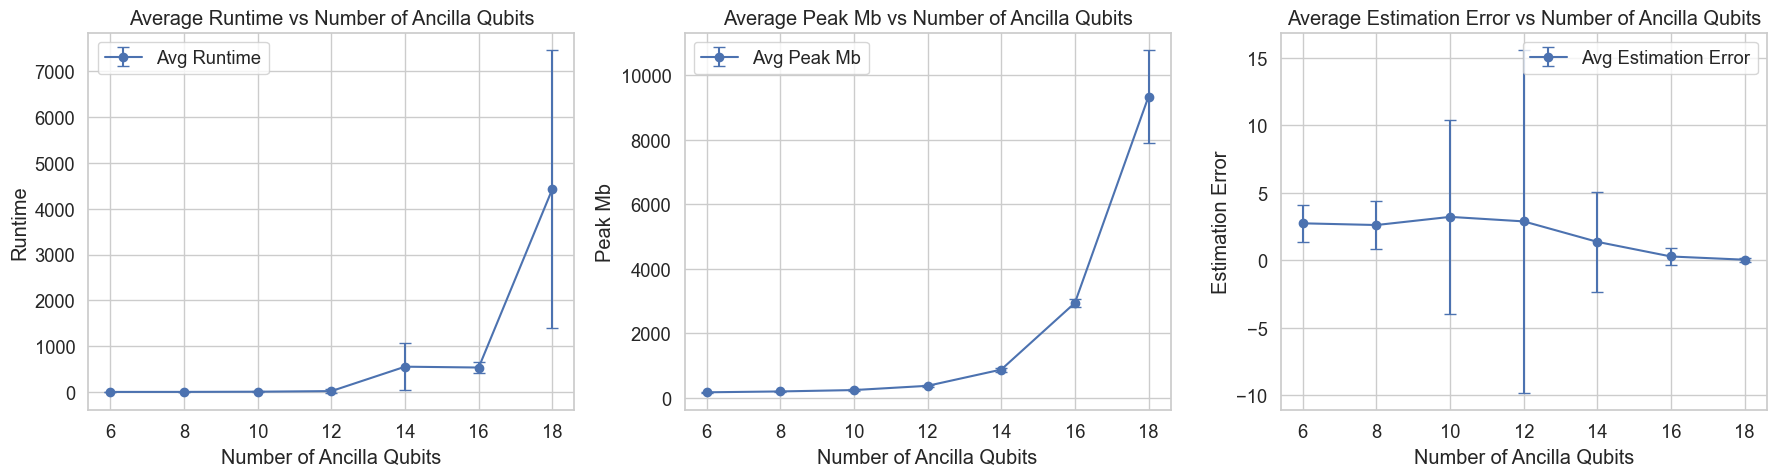

Group: 10


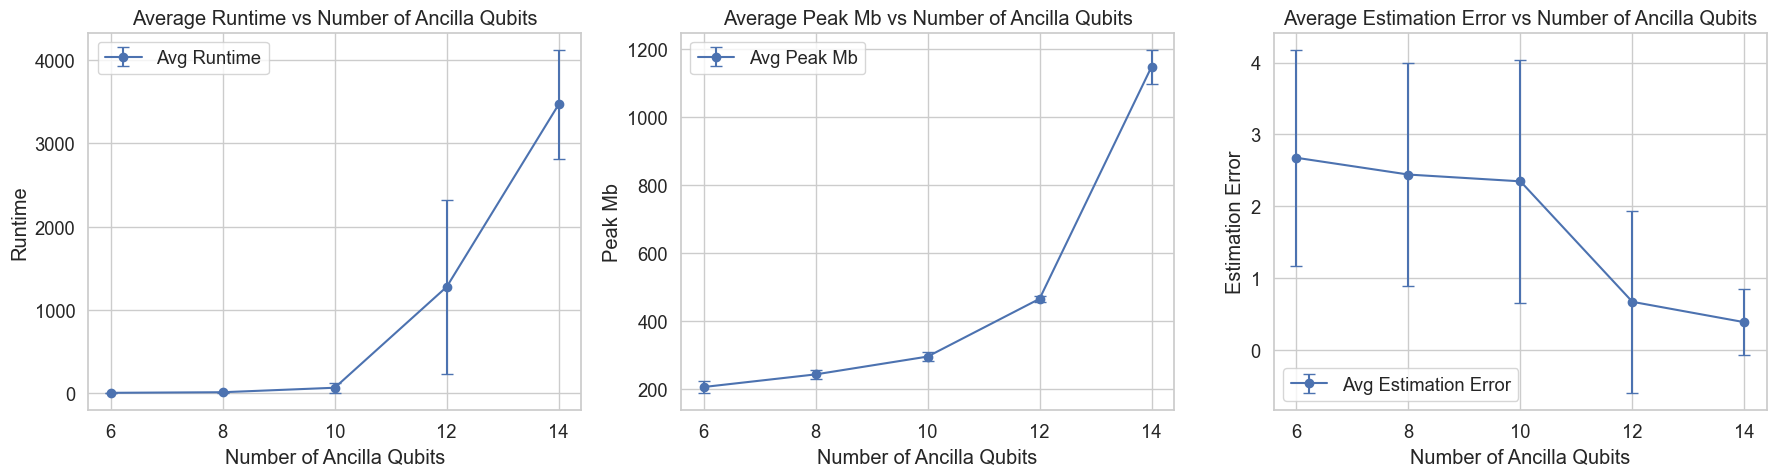

Group: 100


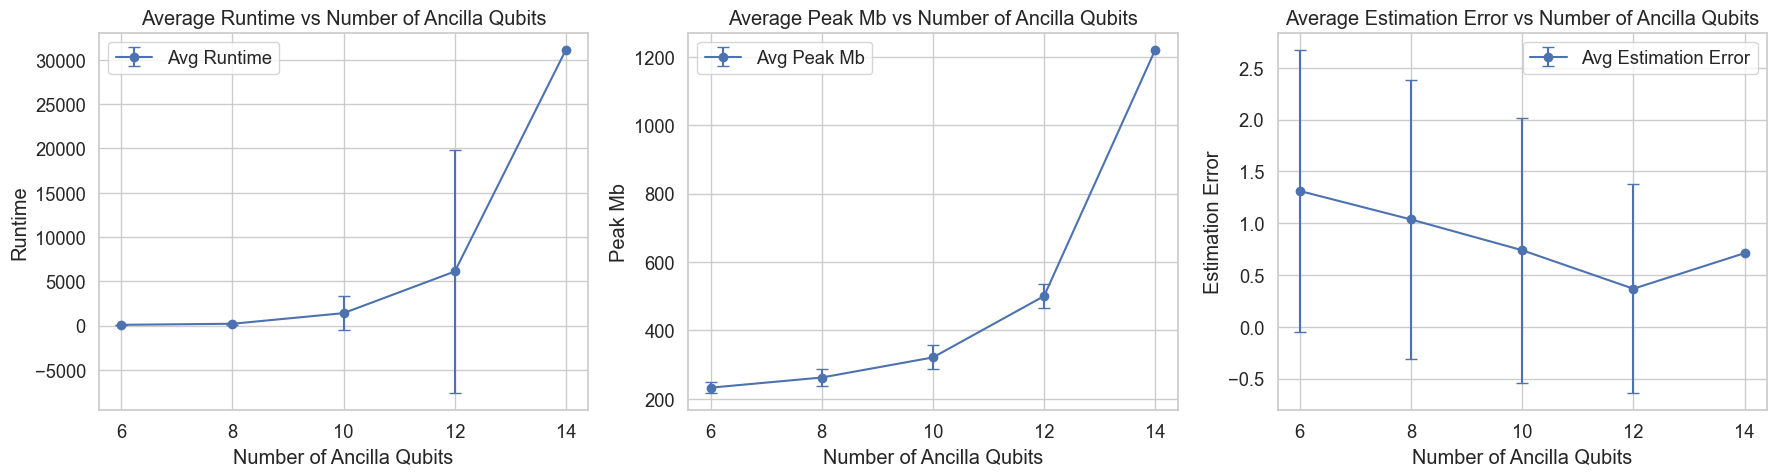

Group: 1000


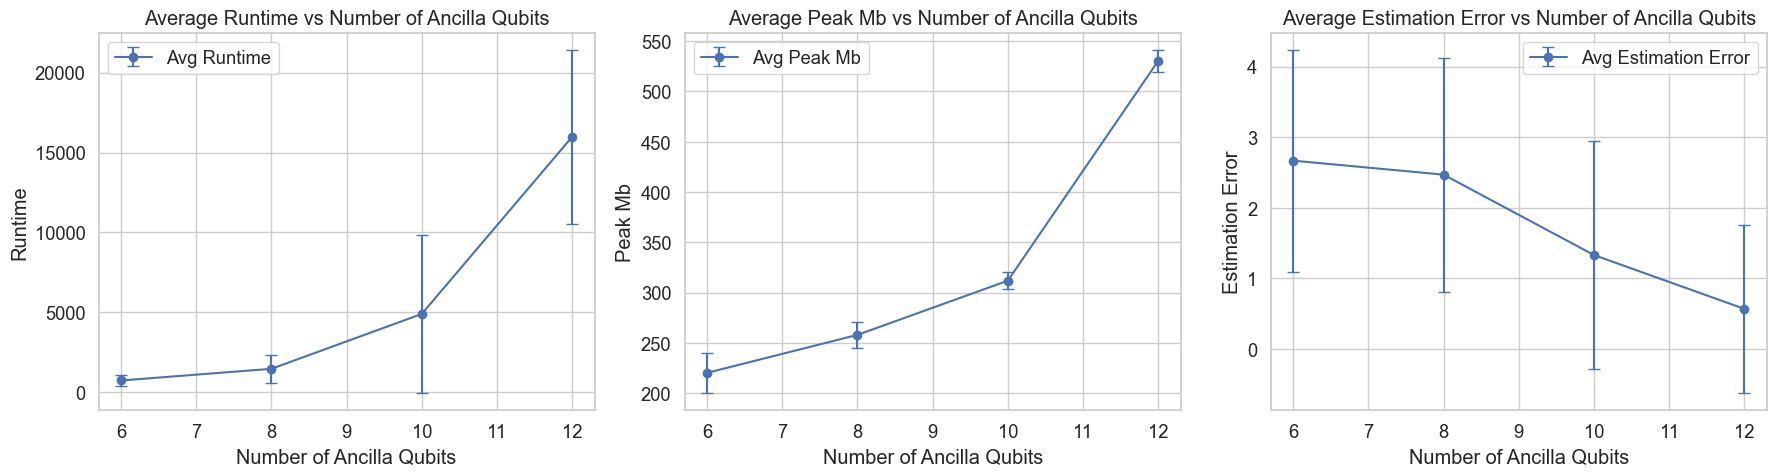

Group: 2000


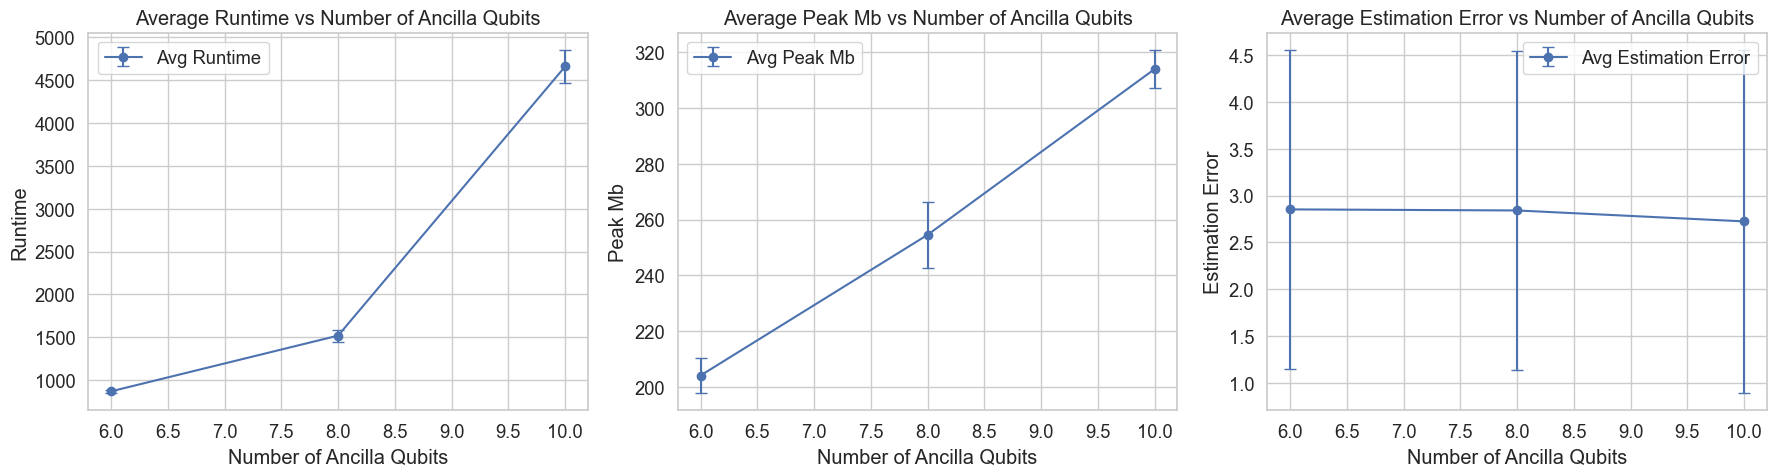

In [76]:
for group_name, group_df in master_df.groupby("n_circuits"):
    print(f"Group: {group_name}")
    plot_avg_metrics_vs_ancilla(group_df, metric_cols=["runtime", "peak_MB", "estimation_error"])


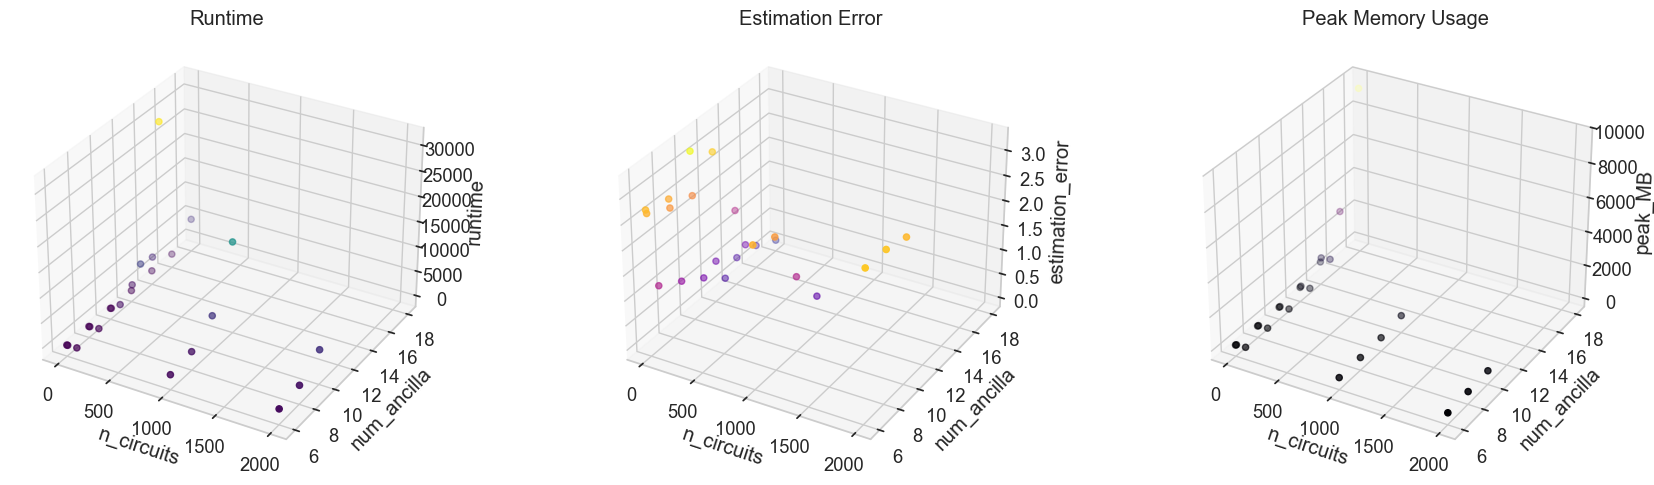

In [77]:
# Group by 'num_ancilla' and 'n_circuits'
grouped = master_df.groupby(["num_ancilla", "n_circuits"]).agg({
    "runtime": "mean",
    "peak_MB": "mean",
    "estimation_error": "mean"
}).reset_index()

# Create the figure
fig = plt.figure(figsize=(18, 5))

# 3D plot for runtime
ax1 = fig.add_subplot(131, projection='3d')
p1 = ax1.scatter(grouped["n_circuits"], grouped["num_ancilla"], grouped["runtime"], 
                 c=grouped["runtime"], cmap='viridis')
ax1.set_xlabel("n_circuits")
ax1.set_ylabel("num_ancilla")
ax1.set_zlabel("runtime")
ax1.set_title("Runtime")

# 3D plot for estimation error
ax2 = fig.add_subplot(132, projection='3d')
p2 = ax2.scatter(grouped["n_circuits"], grouped["num_ancilla"], grouped["estimation_error"], 
                 c=grouped["estimation_error"], cmap='plasma')
ax2.set_xlabel("n_circuits")
ax2.set_ylabel("num_ancilla")
ax2.set_zlabel("estimation_error")
ax2.set_title("Estimation Error")

# 3D plot for peak_MB
ax3 = fig.add_subplot(133, projection='3d')
p3 = ax3.scatter(grouped["n_circuits"], grouped["num_ancilla"], grouped["peak_MB"], 
                 c=grouped["peak_MB"], cmap='inferno')
ax3.set_xlabel("n_circuits")
ax3.set_ylabel("num_ancilla")
ax3.set_zlabel("peak_MB")
ax3.set_title("Peak Memory Usage")

plt.tight_layout()
plt.show()